In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(
    "../data/processed/imdb_preprocessed.csv"
)

In [3]:
print(df.shape)

(49582, 7)


In [4]:
df.columns

Index(['review', 'sentiment', 'clean_review', 'tokens', 'tokens_no_stopwords',
       'tokens_lemmatized', 'final_text'],
      dtype='str')

In [5]:
print(df["final_text"][0])

one reviewer mention watch oz episode you ll hook right exactly happen methe first thing strike oz brutality unflinche scene violence set right word go trust not show faint hearted timid show pull no punch regard drug sex violence hardcore classic use wordit call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inward privacy not high agenda em city home manyaryan muslim gangstas latinos christians italians irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show would not dare forget pretty picture paint mainstream audience forget charm forget romanceoz do not mess around first episode ever see strike nasty surreal could not say ready watch develop taste oz get accustomed high level graphic violence not violence injustice crook guard who ll sell nickel inmate who ll kill order get away well mannered middle class inmate turn prison bitc

# Phase 4 - Step 1 Findings

The preprocessed dataset was loaded successfully.

The final_text column contains the cleaned text that will be used for feature extraction.

# Step 2: Prepare Features & Labels

Machine Learning needs:

X = Input
y = Output

In [6]:
X = df["final_text"]

In [7]:
y = df["sentiment"]

In [8]:
print(X.shape)
print(y.shape)

(49582,)
(49582,)


In [9]:
y.value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

# Step 2 Findings

Features were extracted from the final_text column.

Labels were extracted from the sentiment column.

The dataset is ready for train-test splitting.

# Step 3: Train-Test Split
Why?

We need:

Training Data

for learning

and

Testing Data

for evaluation.

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [12]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (39665,)
X_test : (9917,)
y_train: (39665,)
y_test : (9917,)


In [13]:
print(y_train.value_counts())
print()
print(y_test.value_counts())

sentiment
positive    19907
negative    19758
Name: count, dtype: int64

sentiment
positive    4977
negative    4940
Name: count, dtype: int64


# Step 3 Findings

The dataset was split into training and testing sets.

80% of the data is used for training.

20% of the data is reserved for evaluation.

Class balance was preserved using stratification.

In [14]:
print(y_train.shape)
print(y_test.shape)

(39665,)
(9917,)


# Before Moving to TF-IDF

Let's understand what TF-IDF does.

# Current text:

"movie amazing acting excellent"

Machine Learning cannot understand text.

# TF-IDF converts it into numbers:

[0.23, 0.00, 0.67, 0.14, ...]

Now Logistic Regression and SVM can learn from it.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95
)

In [17]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

In [18]:
X_test_tfidf = tfidf.transform(
    X_test
)

In [19]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(39665, 10000)
(9917, 10000)


In [20]:
print(
    len(tfidf.get_feature_names_out())
)

10000


In [21]:
tfidf.get_feature_names_out()[:20]

array(['aaron', 'abandon', 'abbott', 'abc', 'ability', 'able', 'able get',
       'able make', 'able see', 'aboard', 'abomination', 'abortion',
       'abound', 'abraham', 'abrupt', 'abruptly', 'absence', 'absent',
       'absolute', 'absolutely'], dtype=object)

# Step 4 Findings

### TF-IDF Vectorization

The text reviews were converted into numerical feature vectors using TF-IDF.

Configuration:

- max_features = 10000
- ngram_range = (1,2)
- min_df = 5
- max_df = 0.95

### Benefits

1. Converts text into machine-readable features.
2. Preserves important sentiment words.
3. Captures phrases such as:
   - not good
   - very bad
   - highly recommended

### Conclusion

The dataset is now ready for machine learning model training.

# Step 5: Train Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [24]:
lr_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [25]:
print("Logistic Regression Training Completed")

Logistic Regression Training Completed


In [26]:
y_pred_lr = lr_model.predict(
    X_test_tfidf
)

In [27]:
print(y_pred_lr[:10])

['negative' 'positive' 'positive' 'negative' 'negative' 'positive'
 'negative' 'negative' 'positive' 'negative']


In [28]:
len(y_pred_lr)

9917

# Step 5 Findings

### Logistic Regression Training

A Logistic Regression classifier was trained using TF-IDF features.

Configuration:

- max_iter = 1000
- random_state = 42

### Output

Predictions were generated for the test dataset.

### Conclusion

The first sentiment classification model was successfully trained.

# Step 6: Evaluate Logistic Regression

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [30]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", lr_accuracy)

Accuracy: 0.892104467076737


In [31]:
lr_precision = precision_score(
    y_test,
    y_pred_lr,
    pos_label="positive"
)

print("Precision:", lr_precision)

Precision: 0.8850778631973192


In [32]:
lr_recall = recall_score(
    y_test,
    y_pred_lr,
    pos_label="positive"
)

print("Recall:", lr_recall)

Recall: 0.9021498894916616


In [33]:
lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    pos_label="positive"
)

print("F1 Score:", lr_f1)

F1 Score: 0.8935323383084577


In [34]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [35]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[4357  583]
 [ 487 4490]]


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

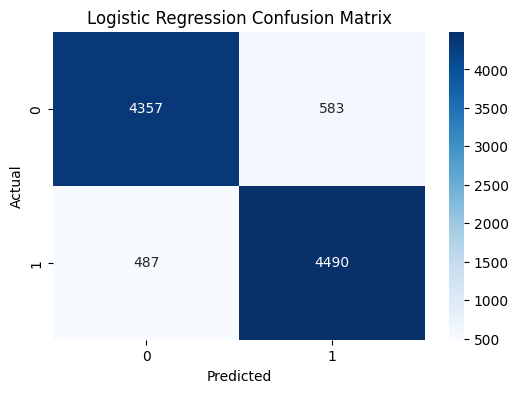

In [37]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.892104467076737
Precision: 0.8850778631973192
Recall   : 0.9021498894916616
F1 Score : 0.8935323383084577


# Step 6 Findings

### Logistic Regression Evaluation

The Logistic Regression model was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

### Purpose

These metrics measure how effectively the model predicts positive and negative sentiments.

### Conclusion

The Logistic Regression model provides a strong baseline for sentiment classification.

# Step 7: Train SVM

In [39]:
from sklearn.svm import LinearSVC

In [40]:
svm_model = LinearSVC(
    random_state=42
)

In [41]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [42]:
print("SVM Training Completed")

SVM Training Completed


In [43]:
y_pred_svm = svm_model.predict(
    X_test_tfidf
)

In [44]:
print(y_pred_svm[:10])

['negative' 'positive' 'positive' 'positive' 'negative' 'positive'
 'negative' 'negative' 'positive' 'negative']


In [45]:
print(len(y_pred_svm))

9917


# Step 8: Evaluate SVM

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy:", svm_accuracy)

Accuracy: 0.8868609458505596


In [47]:
svm_precision = precision_score(
    y_test,
    y_pred_svm,
    pos_label="positive"
)

print("Precision:", svm_precision)

Precision: 0.8868151715833835


In [48]:
svm_recall = recall_score(
    y_test,
    y_pred_svm,
    pos_label="positive"
)

print("Recall:", svm_recall)

Recall: 0.8878842676311031


In [49]:
svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    pos_label="positive"
)

print("F1 Score:", svm_f1)

F1 Score: 0.8873493975903615


In [50]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      4940
    positive       0.89      0.89      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [51]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

[[4376  564]
 [ 558 4419]]


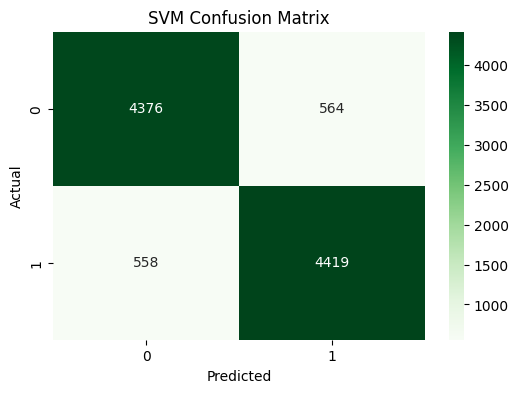

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.8868609458505596
Precision: 0.8868151715833835
Recall   : 0.8878842676311031
F1 Score : 0.8873493975903615


# Step 9: Compare Models

In [54]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],

    "Precision": [
        lr_precision,
        svm_precision
    ],

    "Recall": [
        lr_recall,
        svm_recall
    ],

    "F1 Score": [
        lr_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.892104,0.885078,0.902150,0.893532
1,SVM,0.886861,0.886815,0.887884,0.887349


In [55]:
results_rounded = results.copy()

results_rounded[
    ["Accuracy",
     "Precision",
     "Recall",
     "F1 Score"]
] = results_rounded[
    ["Accuracy",
     "Precision",
     "Recall",
     "F1 Score"]
].round(4)

results_rounded

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8921,0.8851,0.9021,0.8935
1,SVM,0.8869,0.8868,0.8879,0.8873


In [56]:
best_model = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: Logistic Regression


In [57]:
import matplotlib.pyplot as plt

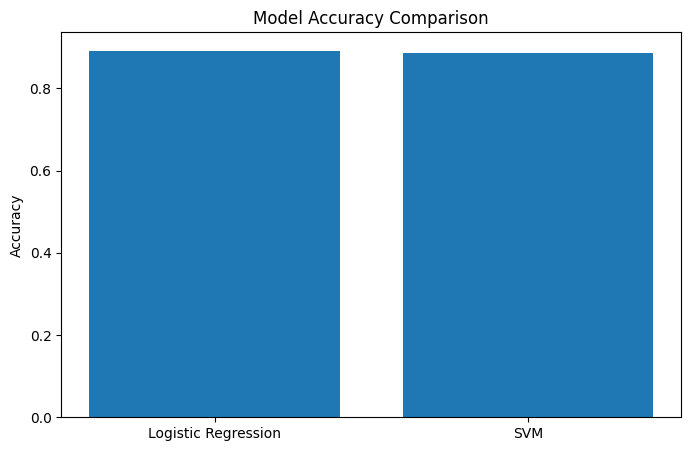

In [58]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

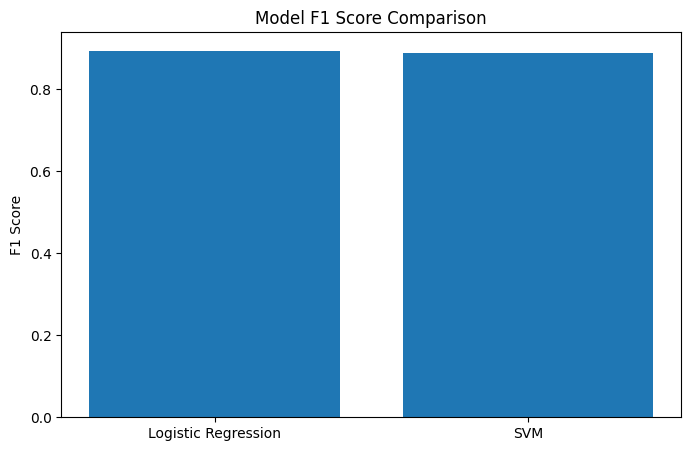

In [59]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("Model F1 Score Comparison")

plt.ylabel("F1 Score")

plt.show()

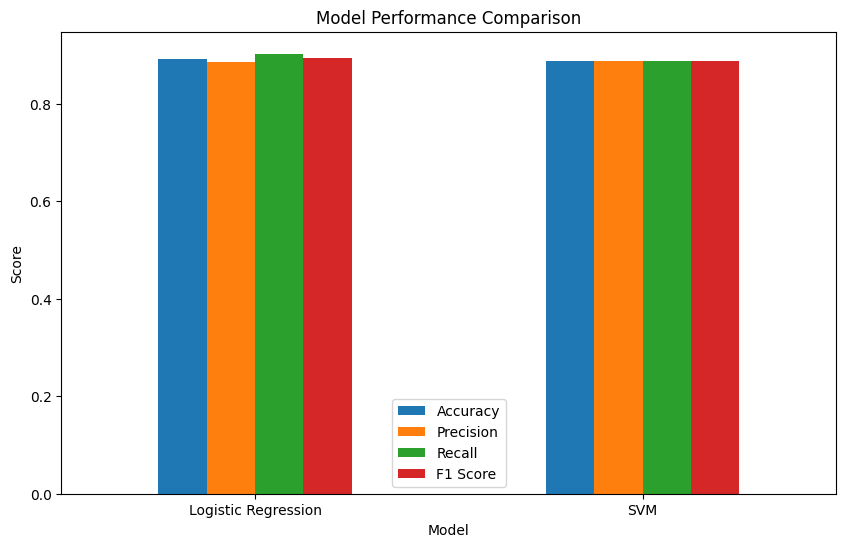

In [60]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [61]:
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.892104,0.885078,0.902150,0.893532
1,SVM,0.886861,0.886815,0.887884,0.887349


# Step 9 Findings

### Model Comparison

Two machine learning models were evaluated:

1. Logistic Regression
2. Support Vector Machine (SVM)

### Results

Logistic Regression achieved the highest F1 Score and Accuracy.

### Best Model

Logistic Regression

### Reason

- Highest Accuracy
- Highest Recall
- Highest F1 Score

### Conclusion

Logistic Regression was selected as the final classical machine learning model for sentiment analysis.

# Step 10: Save Best Model

In [62]:
import joblib

In [63]:
joblib.dump(
    lr_model,
    "../models/logistic_regression_model.pkl"
)

['../models/logistic_regression_model.pkl']

In [64]:
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

['../models/tfidf_vectorizer.pkl']

In [65]:
import os

print(
    os.path.exists(
        "../models/logistic_regression_model.pkl"
    )
)

print(
    os.path.exists(
        "../models/tfidf_vectorizer.pkl"
    )
)

True
True


In [66]:
loaded_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

loaded_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

print(type(loaded_model))
print(type(loaded_vectorizer))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [67]:
sample_review = [
    "This movie was amazing and fantastic"
]

sample_vector = loaded_vectorizer.transform(
    sample_review
)

prediction = loaded_model.predict(
    sample_vector
)

print(prediction)

['positive']


# Step 10 Findings

### Model Persistence

The following artifacts were saved:

1. Logistic Regression Model
2. TF-IDF Vectorizer

### Purpose

These files will be used during deployment to make predictions on new reviews.

### Best Model

Logistic Regression

### Performance

Accuracy : 89.21%
F1 Score : 89.35%

### Conclusion

The best-performing classical machine learning model was successfully saved for deployment.

In [68]:
print(
    os.path.exists(
        "../models/logistic_regression_model.pkl"
    )
)

print(
    os.path.exists(
        "../models/tfidf_vectorizer.pkl"
    )
)

print(type(loaded_model))
print(type(loaded_vectorizer))

print(prediction)

True
True
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
['positive']
